<a href="https://colab.research.google.com/github/JorgeEncinas/pytorch_ztm/blob/main/06_PyTorch_Transfer_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 06. PyTorch Transfer Learning

Transfer Learning

It is taking the parameters of what one model has learned on another dataset, to apply them to our own problem.

* Pretrained model = Foundation models

In [1]:
import torch
import torchvision

print(torch.__version__) #we want 1.12+
print(torchvision.__version__) #should be 0.13+

2.6.0+cu124
0.21.0+cu124


In case we didn't get what we wanted, you can get the unstable versions, but they may have errors.

Once you got the versions you're after, let's import the code we've written in previous section to avoid re-treading ground.

In [2]:
import matplotlib.pyplot as plt
import torch
import torchvision

from torch import nn
from torchvision import transforms

# Getting `torchinfo`
try:
  from torchinfo import summary
except:
  print("[INFO] Couldn't find torchinfo... installing...")
  !pip install -q torchinfo
  from torchinfo import summary

[INFO] Couldn't find torchinfo... installing...


In [3]:
# Importing modular scripts
try:
  from going_modular.going_modular import data_setup, engine
except:
  print("[INFO] Couldn't fine going_modular scripts, downloading from Github...")
  !git clone https://github.com/mrdbourke/pytorch-deep-learning
  !mv pytorch-deep-learning/going_modular .
  !rm -rf pytorch-deep-learning
  from going_modular.going_modular import data_setup, engine

[INFO] Couldn't fine going_modular scripts, downloading from Github...
Cloning into 'pytorch-deep-learning'...
remote: Enumerating objects: 4393, done.
remote: Total 4393 (delta 0), reused 0 (delta 0), pack-reused 4393 (from 1)
Receiving objects: 100% (4393/4393), 764.14 MiB | 45.60 MiB/s, done.
Resolving deltas: 100% (2657/2657), done.
Updating files: 100% (248/248), done.


In [5]:
# Setup device-agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device #I am going with `CPU` since I have limited usage of Google Colab.

'cpu'

# 1. Getting data

We are taking the same Pizza, Steak, Sushi dataset

In [9]:
# !wget https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip
import os
import zipfile
from pathlib import Path
import requests

# Setup data path
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi" #Images from a subset of classes from the Food101 (we're starting with a bit of that dataset only)

if image_path.is_dir() and len(list(image_path.glob("*/*/*.jpg"))) > 5:
  print(f"'{image_path}' directory already exists")
else:
  print(f"'{image_path}' directory was not found. Downloading...")
  image_path.mkdir(parents=True, exist_ok=True)

  with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
    request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/refs/heads/main/data/pizza_steak_sushi.zip")
    print("Downloading pizza, steak, sushi data...")
    f.write(request.content)

  # Unzip the downloaded data
  with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
    print("Unzipping pizza, steak, sushi data")
    zip_ref.extractall(image_path)

  # Remove zip file
  os.remove(data_path / "pizza_steak_sushi.zip")

'data/pizza_steak_sushi' directory was not found. Downloading...
Unzipping pizza, steak, sushi data


In [10]:
#Setup directory path
train_dir = image_path / "train"
test_dir = image_path / "test"

train_dir, test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

## 2. Create Datasets and DataLoaders (bit of a difference for Pretrained models)

We can use `data_setup.py` and the `create_dataloaders` function we created before.

Notice the function takes a `transform`, which is where we'll need to be careful

There are 2 ways to go about transforms
  1. Manually created transforms
    - You define what transforms you want your data to go through
  2. Automatically created transforms.
    - The transforms for your data are defined by the model you'd like to use.

For pretrained models, the data, including your custom data, must be transformed in THE SAME WAY that the data the model was TRAINED ON.

Once we loaded our image, how do we get them into dataloaders? Well, you know we transform them into tensors through a Transform.

In [ ]:
from going_modular.going_modular import data_setup

data_setup.create_dataloaders(
    train_dir = train_dir,
    test_dir = test_dir,
    transform=,
    batch_size = BATCH_SIZE,
    num_workers=NUM_WORKERS
)

## 2.1 Creating a transform for `torchvision.models` (Manual creation)

`torchvision.models` containes pretrained models (models ready for transfer learning) right within `torchvision`

You can go into PyTorch's documentation for it, under

    Docs > Models and pre-trained weights

and you'll find the following specifications for TorchVision

```
  All pre-trained models expect input images normalized in the same way, i.e. mini-batches of 3-channel RGB images of shape (3 * H * W), where H and W are expected to be AT LEAST 224.

  The images have to be loaded into a range of [0, 1] and then normalized using

  mean = [0.485, 0.456, 0.406]
  std = [0.229, 0.224, 0.225]

  You can use the following transform to normalize:

  normalize = transforms.Normalize(
    mean = [0.485, 0.456, 0.406],
    std = [0.229, 0.224, 0.225]
  )
```

As you can see, it must be transformed in the same way the original training data was transformed.

The range [0, 1] means that the values need to be between 0 and 1, and we can do that with the `ToTensor` transformation.

If we normalize our image as specified, our tensors will have the same data distribution as the pretrained models.

The values were learned from the `ImageNet` dataset. If you wanted to calculate the Data Distribution...

Anyway it's just saying format your data so that it has the same distribution (recall the Normal distribution or some other curve). These values have been calculated to be that, and we want our data to have that as well.

Any good documentation on pretrained models will have this information somewhere.

In [11]:
from torchvision import transforms
normalize = transforms.Normalize(
    mean = [0.485, 0.456, 0.406],
    std = [0.229, 0.224, 0.225]
  )

manual_transforms = transforms.Compose([
    transforms.Resize((224, 224)), #At least 224*224
    transforms.ToTensor(), #Get into range
    normalize #Make sure images have the same distribution as ImageNet
])

In [12]:
from going_modular.going_modular import data_setup
import os

BATCH_SIZE=32
NUM_WORKERS = os.cpu_count()


train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(
    train_dir=train_dir,
    test_dir=test_dir,
    transform=manual_transforms,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS
)
train_dataloader, test_dataloader, class_names

(<torch.utils.data.dataloader.DataLoader at 0x795ebc698590>,
 ['pizza', 'steak', 'sushi'])

## 2.2 Creating a transform for torchvision.models (Automatic Creation)

The downside of a manually-created transform is that we may get Performance Degradations if we did it wrong or slightly different.

So PyTorch has introduced a way for automatic transformation based on the Pretrained Model Weight you're using.

In [ ]:
from torchvision.models import resnet50, ResNet50_Weights # For example
#resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
#resnet50(weights="IMAGENET1K_V1") #Another way of initializing it
#resnet50(weights=ResNet50_Weights.IMAGENET1K_V2) # There are even multiple iterations on weight.

For Classification, there are a lot of models that have pre-trained weights. EfficientNet works quite nicely, for example. And you can see from which paper it is and how it was created.

A general heuristic for looking at vision models, if they have versions, B0, B1, B2,...

The higher the number, the bigger the model, and so if it becomes too large it may not run in your application, since it becomes more demanding

In [14]:
import torchvision
torchvision.__version__

'0.21.0+cu124'

In [16]:
# Get a set of pretrained model weights
weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT # "DEFAULT" = Best available
weights

EfficientNet_B0_Weights.IMAGENET1K_V1

In [17]:
# Get the transforms used to create our pretrained weights
auto_transforms = weights.transforms()
auto_transforms

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)

In [19]:
# Create DataLoaders using automatic transforms
train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(
    train_dir=train_dir,
    test_dir=test_dir,
    transform=auto_transforms,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS
)
train_dataloader, test_dataloader, class_names

(<torch.utils.data.dataloader.DataLoader at 0x795ebc72ef90>,
 ['pizza', 'steak', 'sushi'])

It's important that the transformations are the same. For torchvision in particular you can create it manually, but you may do it wrong, or you may do it automatically, as of 0.13+

So call .transforms() on those weights to get the transforms. So make sure when you read the documentation you're on 0.13+ or above.
You can also look at previous versions to see how it was done before.

# 3. Getting a pre-trained model

- PyTorch domain libraries
- Libraries like `timm` (Torch Image Models)
- HuggingFace Hub (for plenty of diff models)
- PapersWithCode (for models across different problem spaces/domains)

## 3.1 Which pretrained model should you use

Experiment, experiment, experiment.
From a problem space similar to your own, you customize it for your problem. Consider 3 things

1. Speed (a slow model isn't really a choice) - how fast does it run
2. Size - how big is the model
3. Performance - how well does it go on your chosen problem

They're usually tied altogether.

Where does the model live?

Is it on device, like a self-driving car?

Or does it live on a server?

Looking at [PyTorch's table](https://docs.pytorch.org/vision/main/models.html)

Which model should we choose?


Generally, the less parameters, the faster a model runs. Higher params, the model is slower in terms of inference and training.

So we're looking for higher accuracy to lower number of parameters. Try to find the best ratio of this in what PyTorch's vision models offer.

For our case, seems EffNetB0 is one of our best options in terms of Performance vs. Size

`The Bitter Lesson` is an essay in AI. It says that general methods that leverage as much computation as they can are the most effective, and by a large margin. The more compute, the more data, the more general your method (algorithm), the better your results will be.

But we're keeping this small

## 3.2 Setting up a pretrained model

We want to create an instance of EfficientNetB0.

In [21]:
# Old method of creating a pretrained model, prior to v0.13
# model = torchvision.models.efficientnet_b0(pretrained=True)

# NEW way
weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT # Again `DEFAULT` gets best available weights.
model = torchvision.models.efficientnet_b0(weights=weights)
model

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 156MB/s]


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

Notice we have three sections

1. Features
2. avgpool
3. classifier

In [22]:
model.features

Sequential(
  (0): Conv2dNormActivation(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): SiLU(inplace=True)
  )
  (1): Sequential(
    (0): MBConv(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): SiLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
          (activation): SiLU(inplace=True)
          (scale_activation): Sigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), 

In [24]:
model.avgpool

AdaptiveAvgPool2d(output_size=1)

That collects all the features and averages them

In [25]:
model.classifier

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)

Our classifier head, which is what we'll alter, we'll alter features and this one. What you notice is that out_features=1000

That's because it's trained in ImageNet, which has 1000 classes, but we have 3

We need to adapt that.

`Features` is all about extracting features from an image.
A `feature` is anything you can imagine. For example, the fact pizzas are circular, sushi is often small, steak is often a darker color.

And then, `avgpool` converts this features into a single feature vector. It compresses into a vector of size 1280, because the classifier Layer takes that.

Then the final classifier layer turns that compressed data with learned representations, and we adjust this final classifier layer

To turn it into an output of prediction probabilities for pizza, steak, and sushi.

This classifier head further compresses the vector into either 1000 output units (originally), or to three. The last layer, then, in other words, gives us our logits.

### Types of Transfer Learning
The output is slightly different. The idea of Feature Extractor Transfer Learning model is quite similar regardless of the backbone you're using

You'll hear quite a few different terms around Transfer Learning, they all mean different versions of the same thing.

- Overall architecture
- Feature Extraction
  - We don't tell our model what a feature is, it could be almost anything.
  - In our case, a feature extractor, we keep all these backbone layers FROZEN, as they've learned patterns through its pretraining. (ImageNet)
  - All we care to change is our output layer
- AvgPool
  - Turns the feature our model has learned into a single compressed vector.
- Classifier Layer or Classification Head
  - We can tune and change the number of output features to what we need.

### Original Model vs Feature Extraction

Original starts with a large dataset

For feature extraction, we keep all base layers frozen. These parameters won't get updated during training.

Then we will change the input data and the output classifier layer, which now has 3 output features only. The data becomes our custom data.

### One more type

- Original
- Feature Extraction
- Fine Tuning

Fine-tuning is suitable when you have more training data. You can unfreeze some of the base layer and update them to suit the data. But if you don't have large amounts of data, you're better off doing just Feature Extraction, keeping it simple.

## 3.3 Getting a summary of our model with `torchinfo.summary()`

In [26]:
# Print a summary with torchinfo
from torchinfo import summary

summary(
    model=model,
    input_size=(1, 3, 224, 224), #Example [Batch Size, C, H, W]
    col_names=["input_size", "output_size", "num_params", "trainable"],
    col_width=20, #just for formatting
    row_settings=["var_names"]
)

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [1, 3, 224, 224]     [1, 1000]            --                   True
├─Sequential (features)                                      [1, 3, 224, 224]     [1, 1280, 7, 7]      --                   True
│    └─Conv2dNormActivation (0)                              [1, 3, 224, 224]     [1, 32, 112, 112]    --                   True
│    │    └─Conv2d (0)                                       [1, 3, 224, 224]     [1, 32, 112, 112]    864                  True
│    │    └─BatchNorm2d (1)                                  [1, 32, 112, 112]    [1, 32, 112, 112]    64                   True
│    │    └─SiLU (2)                                         [1, 32, 112, 112]    [1, 32, 112, 112]    --                   --
│    └─Sequential (1)                                        [1, 32, 112, 112]    [1, 16, 112,

## 3.4 Freezing the base model and changing the output layer to suit our needs

With a feature extraction model, typically you will freeze the base layers of a pre-trained/foundation model, and update the OUTPUT LAYERS to suit your own problem.

In [27]:
# Freeze all of the base layers in EffNetB0
model.features

Sequential(
  (0): Conv2dNormActivation(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): SiLU(inplace=True)
  )
  (1): Sequential(
    (0): MBConv(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): SiLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
          (activation): SiLU(inplace=True)
          (scale_activation): Sigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), 

We want to freeze all of these.

In [29]:
for param in model.features.parameters():
  #print(param)
  param.requires_grad = False
# With `False`, PyTorch won't keep track of the operations with these tensors,
# and won't update them.

In [30]:
# Print a summary with torchinfo
from torchinfo import summary

summary(
    model=model,
    input_size=(1, 3, 224, 224), #Example [Batch Size, C, H, W]
    col_names=["input_size", "output_size", "num_params", "trainable"],
    col_width=20, #just for formatting
    row_settings=["var_names"]
)

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [1, 3, 224, 224]     [1, 1000]            --                   Partial
├─Sequential (features)                                      [1, 3, 224, 224]     [1, 1280, 7, 7]      --                   False
│    └─Conv2dNormActivation (0)                              [1, 3, 224, 224]     [1, 32, 112, 112]    --                   False
│    │    └─Conv2d (0)                                       [1, 3, 224, 224]     [1, 32, 112, 112]    (864)                False
│    │    └─BatchNorm2d (1)                                  [1, 32, 112, 112]    [1, 32, 112, 112]    (64)                 False
│    │    └─SiLU (2)                                         [1, 32, 112, 112]    [1, 32, 112, 112]    --                   --
│    └─Sequential (1)                                        [1, 32, 112, 112]    [1, 1

Look at all the layers that say `False`. Meanwhile the AdaptiveAvgPool2d and the Sequential layer both say `True`

Adapting the head, we must keep it similar, what we mean by that, is that it must still `fit` with what it is expected to receive from the previous layer(s)

In [31]:
# Update the classifier head of our model to suit it.
from torch import nn
torch.manual_seed(42) #Random initialization of weights, so for reproducibility...

model.classifier = nn.Sequential(
    nn.Dropout(p=0.2, inplace=True),
    nn.Linear(
        in_features=1280, #Due to the Dropout before, 20% of the values are randomly zeroed.
        # Also it is 1280 because that's what the rest of the network will pass to this layer.
        out_features=len(class_names)
    )
)
model.classifier

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=3, bias=True)
)

In [32]:
# Print a summary with torchinfo
from torchinfo import summary

summary(
    model=model,
    input_size=(1, 3, 224, 224), #Example [Batch Size, C, H, W]
    col_names=["input_size", "output_size", "num_params", "trainable"],
    col_width=20, #just for formatting
    row_settings=["var_names"]
)

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [1, 3, 224, 224]     [1, 3]               --                   Partial
├─Sequential (features)                                      [1, 3, 224, 224]     [1, 1280, 7, 7]      --                   False
│    └─Conv2dNormActivation (0)                              [1, 3, 224, 224]     [1, 32, 112, 112]    --                   False
│    │    └─Conv2d (0)                                       [1, 3, 224, 224]     [1, 32, 112, 112]    (864)                False
│    │    └─BatchNorm2d (1)                                  [1, 32, 112, 112]    [1, 32, 112, 112]    (64)                 False
│    │    └─SiLU (2)                                         [1, 32, 112, 112]    [1, 32, 112, 112]    --                   --
│    └─Sequential (1)                                        [1, 32, 112, 112]    [1, 1

The total number of parameters has changed, as you can see

# 4. Train model

In [33]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    params=model.parameters(),
    lr=0.001
)

In [34]:
from going_modular.going_modular import engine

torch.manual_seed(42)
torch.cuda.manual_seed(42)

from timeit import default_timer as timer
start_time = timer()

model_results = engine.train(
    model=model,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    epochs=5,
    device=device
)

end_time = timer()
print(f"Training Time: {end_time-start_time:.3f}")
model_results

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.0966 | train_acc: 0.3867 | test_loss: 0.8843 | test_acc: 0.6828
Epoch: 2 | train_loss: 0.9192 | train_acc: 0.6523 | test_loss: 0.7914 | test_acc: 0.8258
Epoch: 3 | train_loss: 0.7542 | train_acc: 0.8711 | test_loss: 0.6483 | test_acc: 0.9167
Epoch: 4 | train_loss: 0.7378 | train_acc: 0.7109 | test_loss: 0.5965 | test_acc: 0.8958
Epoch: 5 | train_loss: 0.6268 | train_acc: 0.7617 | test_loss: 0.6127 | test_acc: 0.8968
Training Time: 107.718


{'train_loss': [1.0965989232063293,
  0.919204406440258,
  0.7541997283697128,
  0.7377771213650703,
  0.6267921291291714],
 'train_acc': [0.38671875, 0.65234375, 0.87109375, 0.7109375, 0.76171875],
 'test_loss': [0.8842612504959106,
  0.7913958231608073,
  0.6483494440714518,
  0.596530556678772,
  0.6126677592595419],
 'test_acc': [0.6827651515151515,
  0.8257575757575758,
  0.9166666666666666,
  0.8958333333333334,
  0.8967803030303031]}

# 5. Plotting the Loss Curve to evaluate the model

For some reason, it didn't work for me, so I brought the function here

In [44]:
import matplotlib.pyplot as plt
# Plot loss curves of a model
def plot_loss_curves(results):
    """Plots training curves of a results dictionary.

    Args:
        results (dict): dictionary containing list of values, e.g.
            {"train_loss": [...],
             "train_acc": [...],
             "test_loss": [...],
             "test_acc": [...]}
    """
    loss = results["train_loss"]
    test_loss = results["test_loss"]

    accuracy = results["train_acc"]
    test_accuracy = results["test_acc"]

    epochs = range(len(results["train_loss"]))

    plt.figure(figsize=(15, 7))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label="train_loss")
    plt.plot(epochs, test_loss, label="test_loss")
    plt.title("Loss")
    plt.xlabel("Epochs")
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, label="train_accuracy")
    plt.plot(epochs, test_accuracy, label="test_accuracy")
    plt.title("Accuracy")
    plt.xlabel("Epochs")
    plt.legend()

In [36]:
try:
  from helper_functions import plot_loss_curves
  print("Helper functions and `plot_loss_curves` were found!")
except:
  print("[INFO] Failed to find `helper_functions.py` and `plot_loss_curves`")
  import requests
  with open("helper_functions.py", "wb") as f:
    request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
    f.write(request.content)
  from helper_functions import plot_loss_curves


[INFO] Failed to find `helper_functions.py` and `plot_loss_curves`


ImportError: cannot import name 'plot_loss_curves' from 'helper_functions' (/content/helper_functions.py)

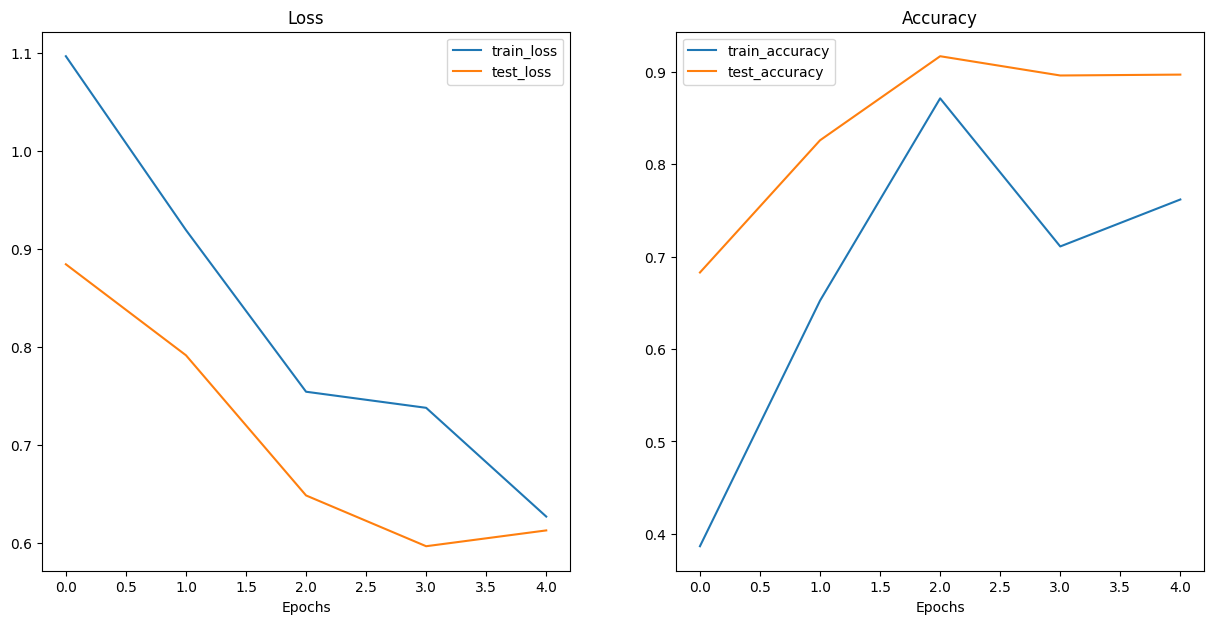

In [45]:
plot_loss_curves(
    results=model_results
)

To me the model started to overfit at the end, which is why the test_loss started to trend upwards, while the train_loss kept getting lower.

You can also see that the test accuracy took a dip, while the train_accuracy did so too, but then it started to improve. That dip is quite odd to me.

# 6. Making predictions on images from the Test Set

We have to make sure our test/custom data is:
* Same shape - images need to be the same shape as the model was trained on
* Same datatype - custom data should be in the same datatype
* Same device - custom data/test data should be on the same device as the model
* Same Transform - If you applied some to your training data, ideally you will transform the test data and custom data the same.

To do all of this, how about creating a function?

`pred_and_plot_image()`

1. Take in a trained model, a list of class names, a filepath to a target image, an image size, a transform, and a target device
2. Open the image with `PIL.Image.Open()`
3. Create a transform if one doesn't exist
4. Make sure the model is on the target device
5. Turn the model to `model.eval()`, which turns off Dropout and use `torch.inference_mode()`
6. Transform the target image, and ensure the dimensionality fits what the model expects.
7. Make a prediction and transform logits into pred_probs and a label
8. Plot everything together.


In [57]:
from typing import List, Tuple
from PIL import Image
from torchvision import transforms

def plot_prediction(
    model : torch.nn.Module,
    image_path : str,
    class_names : List[str],
    image_size : Tuple[int, int] = (224, 224),
    transform : torchvision.transforms = None,
    device : torch.device=device
):
  img = Image.open(image_path)
  if not transform:
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        normalize
    ])

  # Predict on image
  transformed_img = transform(img)
  model.to(device)
  model.eval()
  with torch.inference_mode():
    y_logits = model(transformed_img.unsqueeze(dim=0).to(device))
    y_pred_probs = torch.softmax(y_logits, dim=1)
    y_pred=torch.argmax(y_pred_probs, dim=1).squeeze().item()
    plt.figure()
    plt.imshow(img)
    plt.axis(False)
    plt.title(f"Pred: {class_names[y_pred]} | Prob: {y_pred_probs.squeeze()[y_pred]:.3f}")

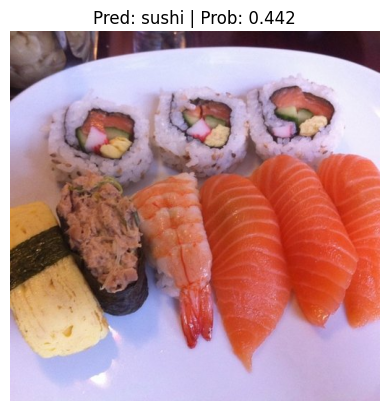

In [69]:
import random

test_image_path_list = list(Path(test_dir).glob("*/*.jpg"))
random_sample = random.sample(test_image_path_list, k=1)[0]
#print(type(random_sample))
plot_prediction(
    model=model,
    image_path=random_sample,
    class_names=class_names,
)

One of the real tests of an ML model is getting a custom image and then looking at the results.

Let's make a prediction at the Pizza Dad img.

In [70]:
# Download the image
import requests

# Setup custom image path
custom_img_path = data_path / "04_pizza_dad.jpeg"

if not custom_img_path.is_file():
  with open(custom_img_path, "wb") as f:
    request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/images/04-pizza-dad.jpeg")
    print(f"Downloading '{custom_img_path}'")
    f.write(request.content)
else:
  print(f"'{custom_img_path}' already exists. No download needed")

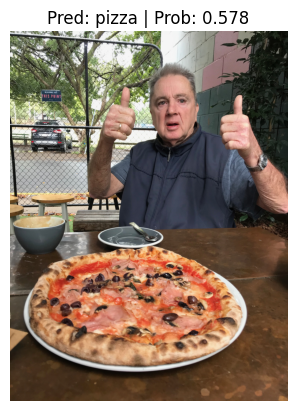

In [71]:
plot_prediction(
    model=model,
    image_path=custom_img_path,
    class_names=class_names
)